In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
import pylab
from matplotlib import pyplot

In [9]:
# importing the data
raw_csv_data = pd.read_excel("CallCenterData.xlsx")

In [10]:
# check point of data
df_comp = raw_csv_data.copy()

In [11]:
df_comp.tail()

,month,Healthcare,Telecom,Banking,Technology,Insurance,#ofphonelines,#noofchannels
127,2020-08-31,20257,4486,1111,212,371,4,3
128,2020-09-30,19207,4474,1020,135,362,3,1
129,2020-10-31,23414,5138,1310,188,523,3,4
130,2020-11-30,23602,4883,1297,199,479,7,1
131,2020-12-31,20058,4150,1118,159,349,4,2


In [8]:
df_comp.describe()

,month,Healthcare,Telecom,Banking,Technology,Insurance,#ofphonelines,#noofchannels
count,132,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000
mean,2015-07-16 06:10:54.545454592,9856.704545,2411.856061,514.204545,112.454545,651.681818,2.250000,2.537879
min,2010-01-31 00:00:00,631.000000,2.000000,4.000000,2.000000,19.000000,0.000000,1.000000
25%,2012-10-23 06:00:00,3744.250000,608.750000,119.000000,39.750000,363.500000,1.000000,1.000000
50%,2015-07-15 12:00:00,9651.500000,2613.500000,486.000000,130.500000,581.000000,2.000000,3.000000
75%,2018-04-07 12:00:00,15590.750000,4000.500000,901.500000,171.250000,997.750000,3.000000,4.000000
max,2020-12-31 00:00:00,23602.000000,5138.000000,1310.000000,229.000000,1535.000000,11.000000,4.000000
std,NaN,6221.071304,1714.759241,392.882978,69.680773,395.949633,1.867255,1.161766


In [9]:
df_comp.isna().sum()

month            0
Healthcare       0
Telecom          0
Banking          0
Technology       0
Insurance        0
#ofphonelines    0
#noofchannels    0
dtype: int64

## Setting date as Index

In [12]:
# taken as a date time field
df_comp.month.describe()

count                              132
mean     2015-07-16 06:10:54.545454592
min                2010-01-31 00:00:00
25%                2012-10-23 06:00:00
50%                2015-07-15 12:00:00
75%                2018-04-07 12:00:00
max                2020-12-31 00:00:00
Name: month, dtype: object

In [13]:
df_comp.set_index("month", inplace=True)

In [14]:
df_comp.head()

,Healthcare,Telecom,Banking,Technology,Insurance,#ofphonelines,#noofchannels
month,,,,,,,
2010-01-31,631,8,6,2,19,1,4
2010-02-28,633,9,7,3,27,1,3
2010-03-31,766,4,4,2,24,1,1
2010-04-30,768,12,6,3,32,1,1
2010-05-31,1003,2,7,2,42,1,4


In [15]:
# seeting the frequency as monthly
df_comp.asfreq('M')

C:\Users\drodr\AppData\Local\Temp\ipykernel_21316\3672824205.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_comp.asfreq('M')


,Healthcare,Telecom,Banking,Technology,Insurance,#ofphonelines,#noofchannels
month,,,,,,,
2010-01-31,631,8,6,2,19,1,4
2010-02-28,633,9,7,3,27,1,3
2010-03-31,766,4,4,2,24,1,1
2010-04-30,768,12,6,3,32,1,1
2010-05-31,1003,2,7,2,42,1,4
...,...,...,...,...,...,...,...
2020-08-31,20257,4486,1111,212,371,4,3
2020-09-30,19207,4474,1020,135,362,3,1
2020-10-31,23414,5138,1310,188,523,3,4


In [16]:
# seeting the frequency as monthly
df_comp = df_comp.asfreq('M')

C:\Users\drodr\AppData\Local\Temp\ipykernel_21316\3020929057.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_comp = df_comp.asfreq('M')


In [17]:
# checking for the null values
df_comp.isna().sum()

Healthcare       0
Telecom          0
Banking          0
Technology       0
Insurance        0
#ofphonelines    0
#noofchannels    0
dtype: int64

## Time Series Visualization

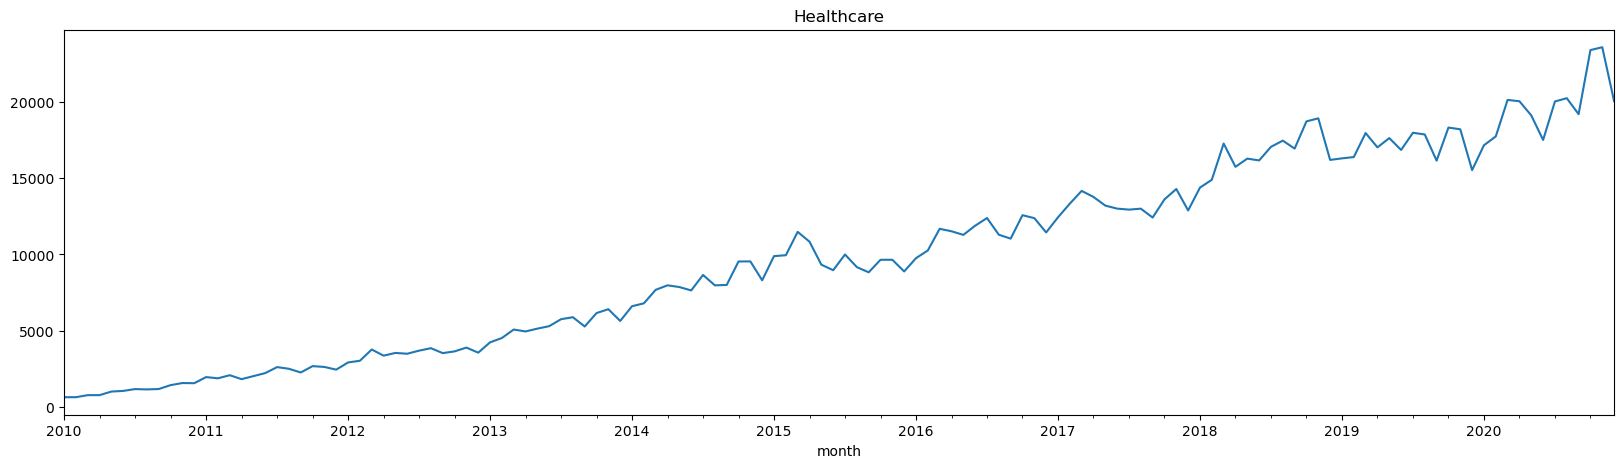

In [18]:
df_comp.Healthcare.plot(figsize=(20,5), title="Healthcare")
plt.show()

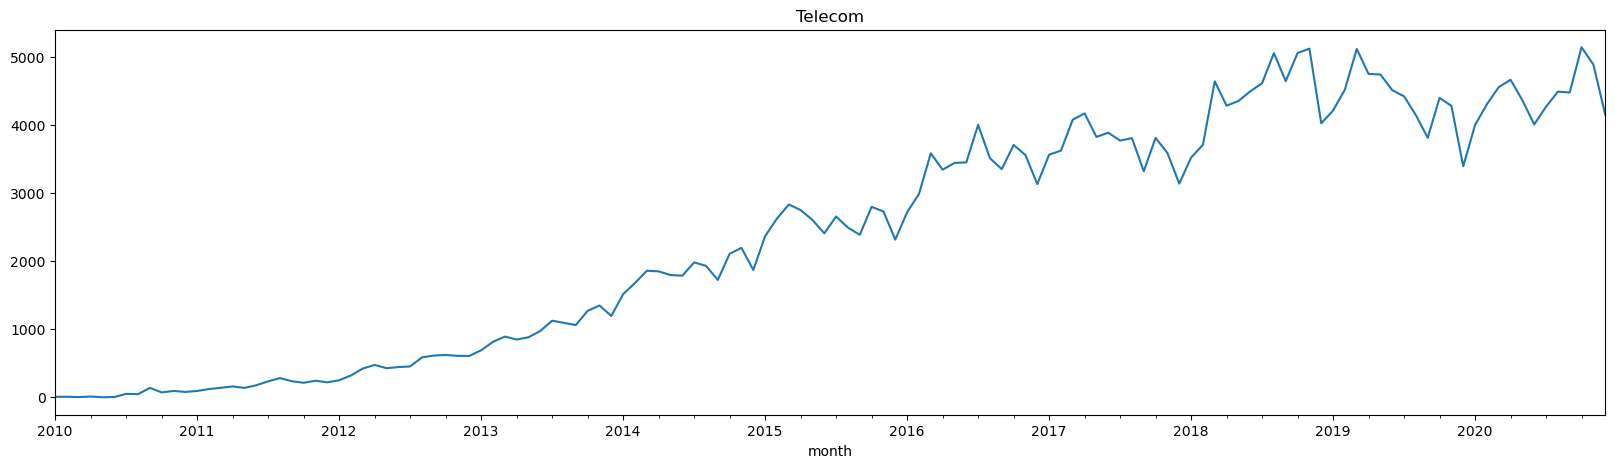

In [16]:
df_comp.Telecom.plot(figsize=(20,5), title="Telecom")
plt.show()

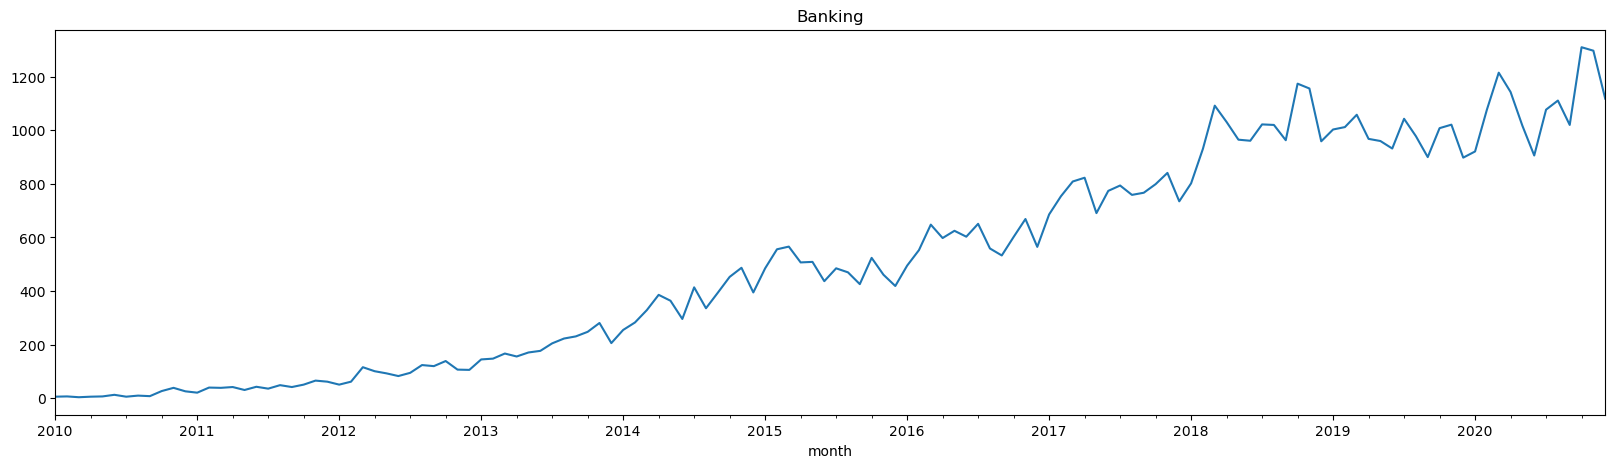

In [17]:
df_comp.Banking.plot(figsize=(20,5), title="Banking")
plt.show()

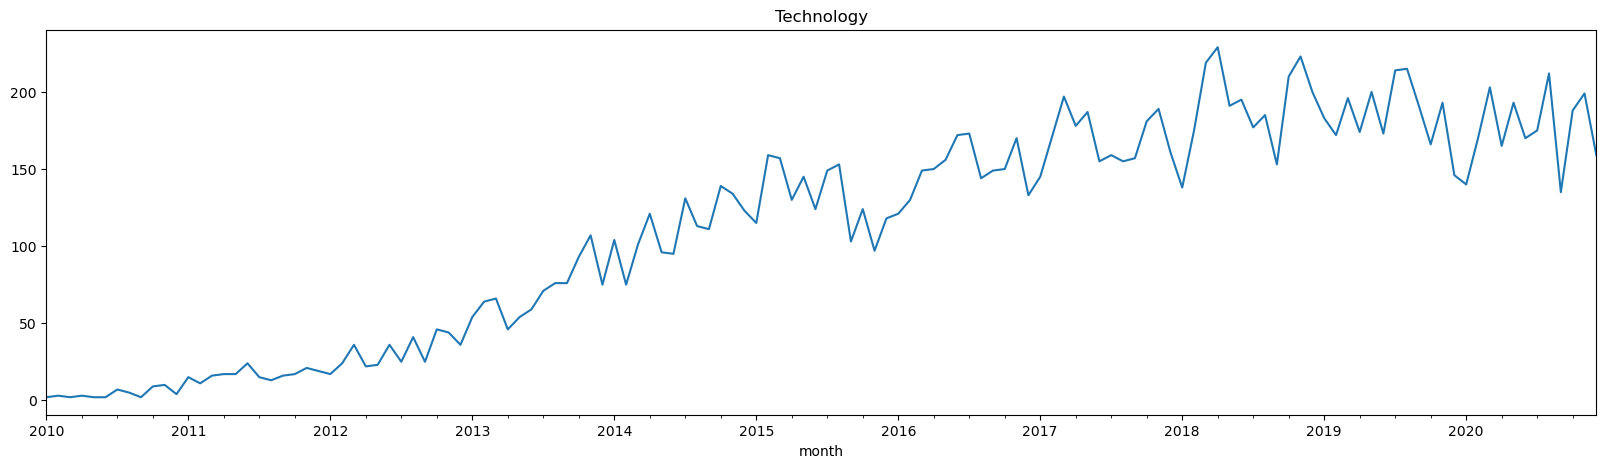

In [18]:
df_comp.Technology.plot(figsize=(20,5), title="Technology")
plt.show()

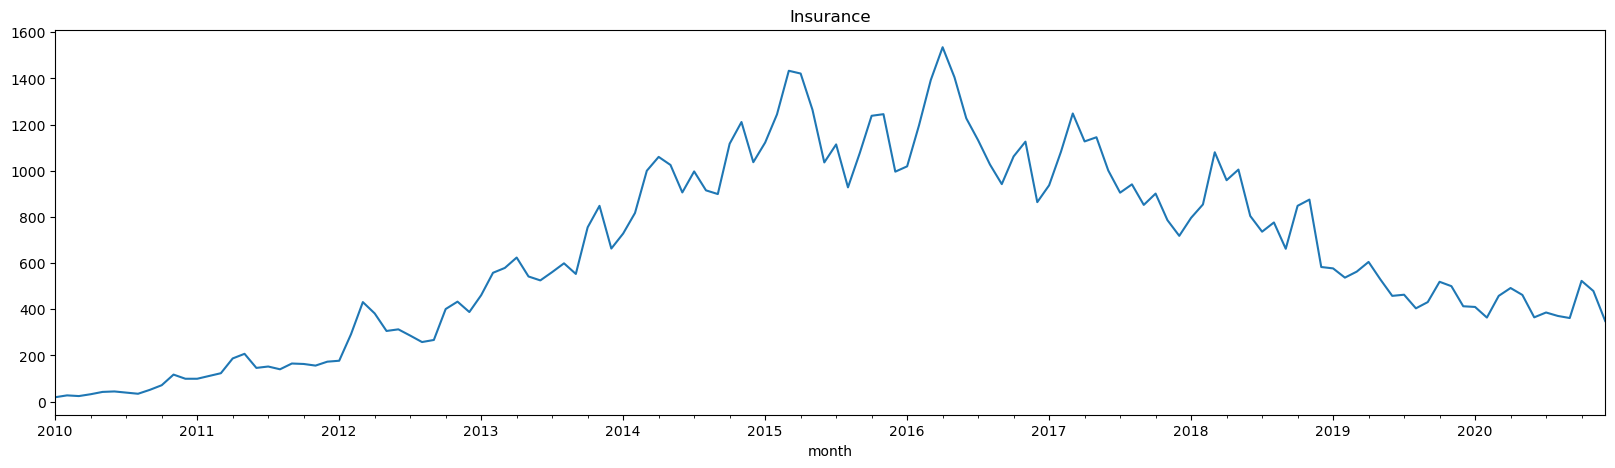

In [19]:
df_comp.Insurance.plot(figsize=(20,5), title="Insurance")
plt.show()

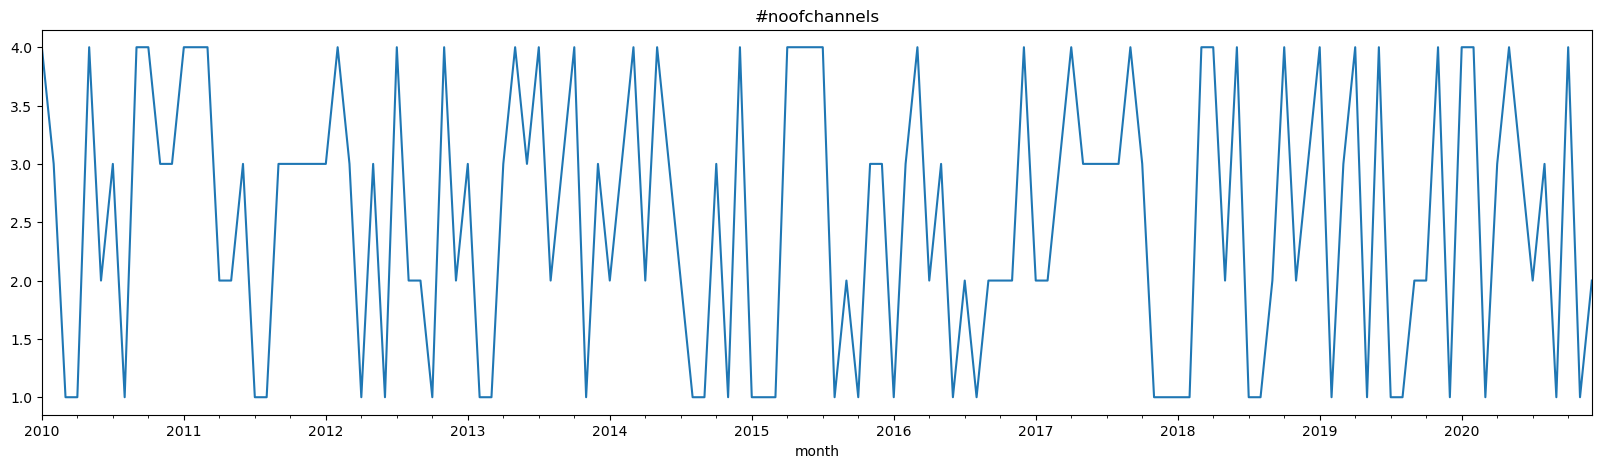

In [20]:
df_comp["#noofchannels"].plot(figsize=(20,5), title="#noofchannels")
plt.show()

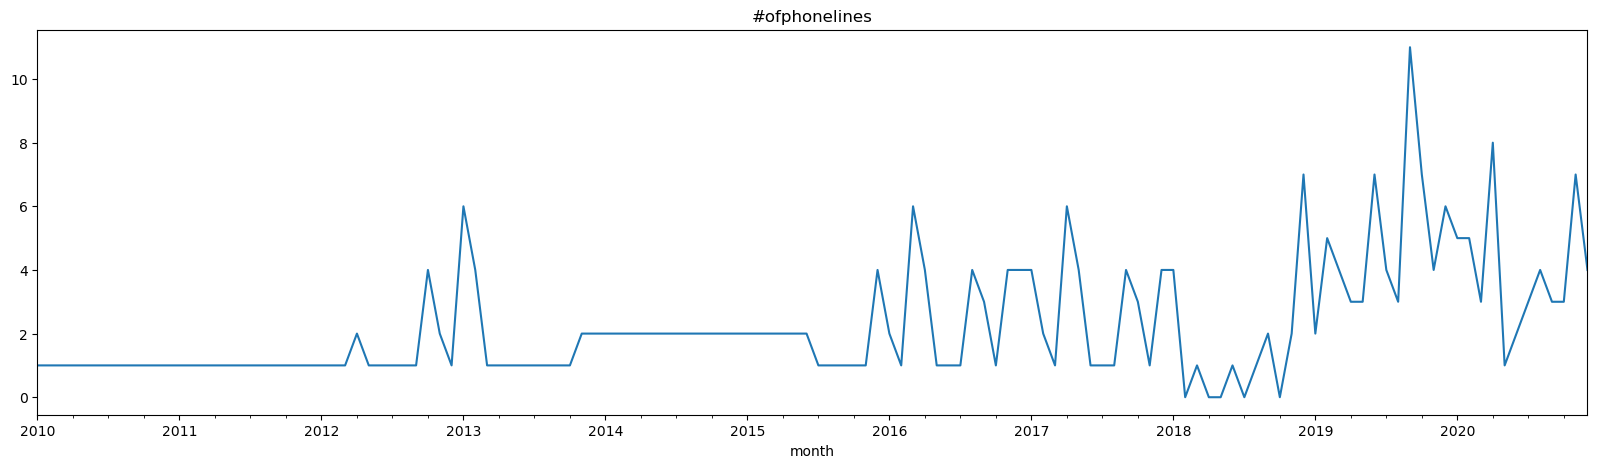

In [21]:
df_comp["#ofphonelines"].plot(figsize=(20,5), title="#ofphonelines")
plt.show()

## Check for normality

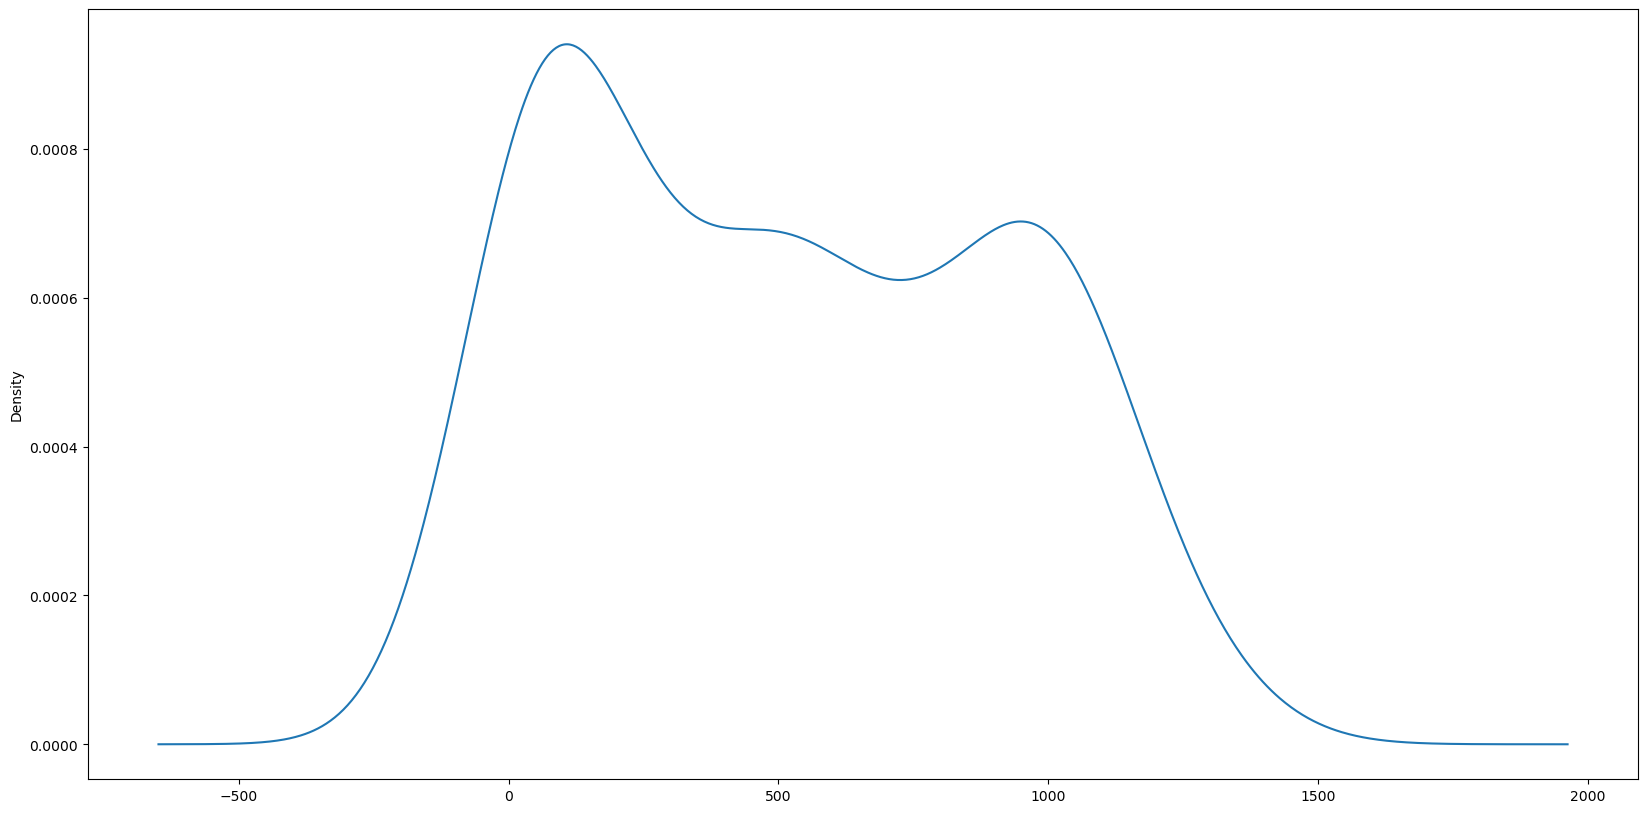

In [22]:
# Density Plots
df_comp["Banking"].plot(kind='kde', figsize=(20, 10))
pyplot.show()

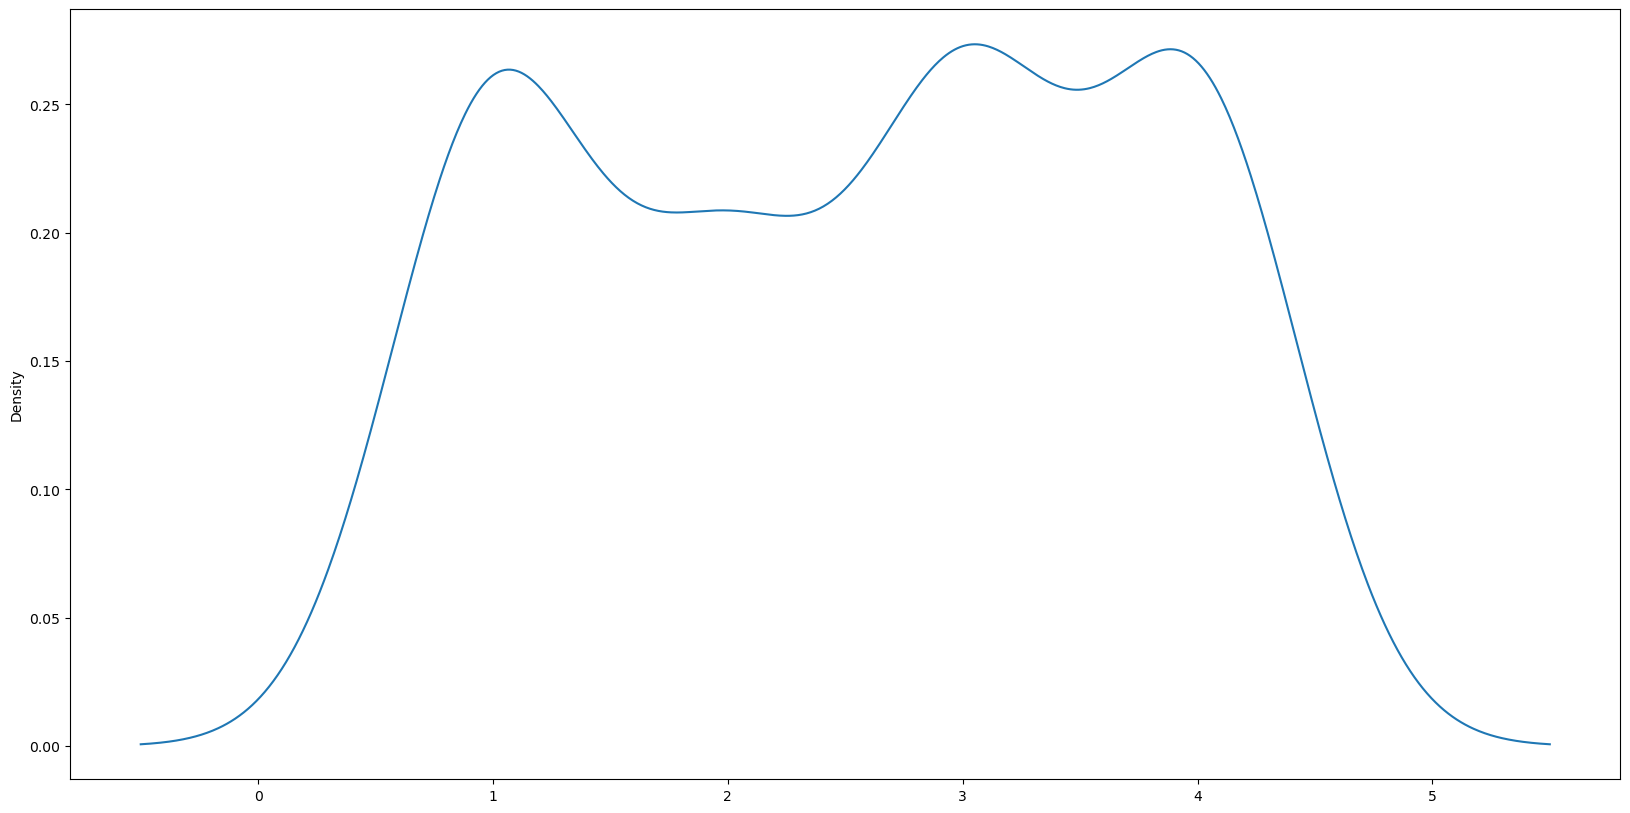

In [23]:
# Density Plots
df_comp["#noofchannels"].plot(kind='kde', figsize=(20, 10))
pyplot.show()

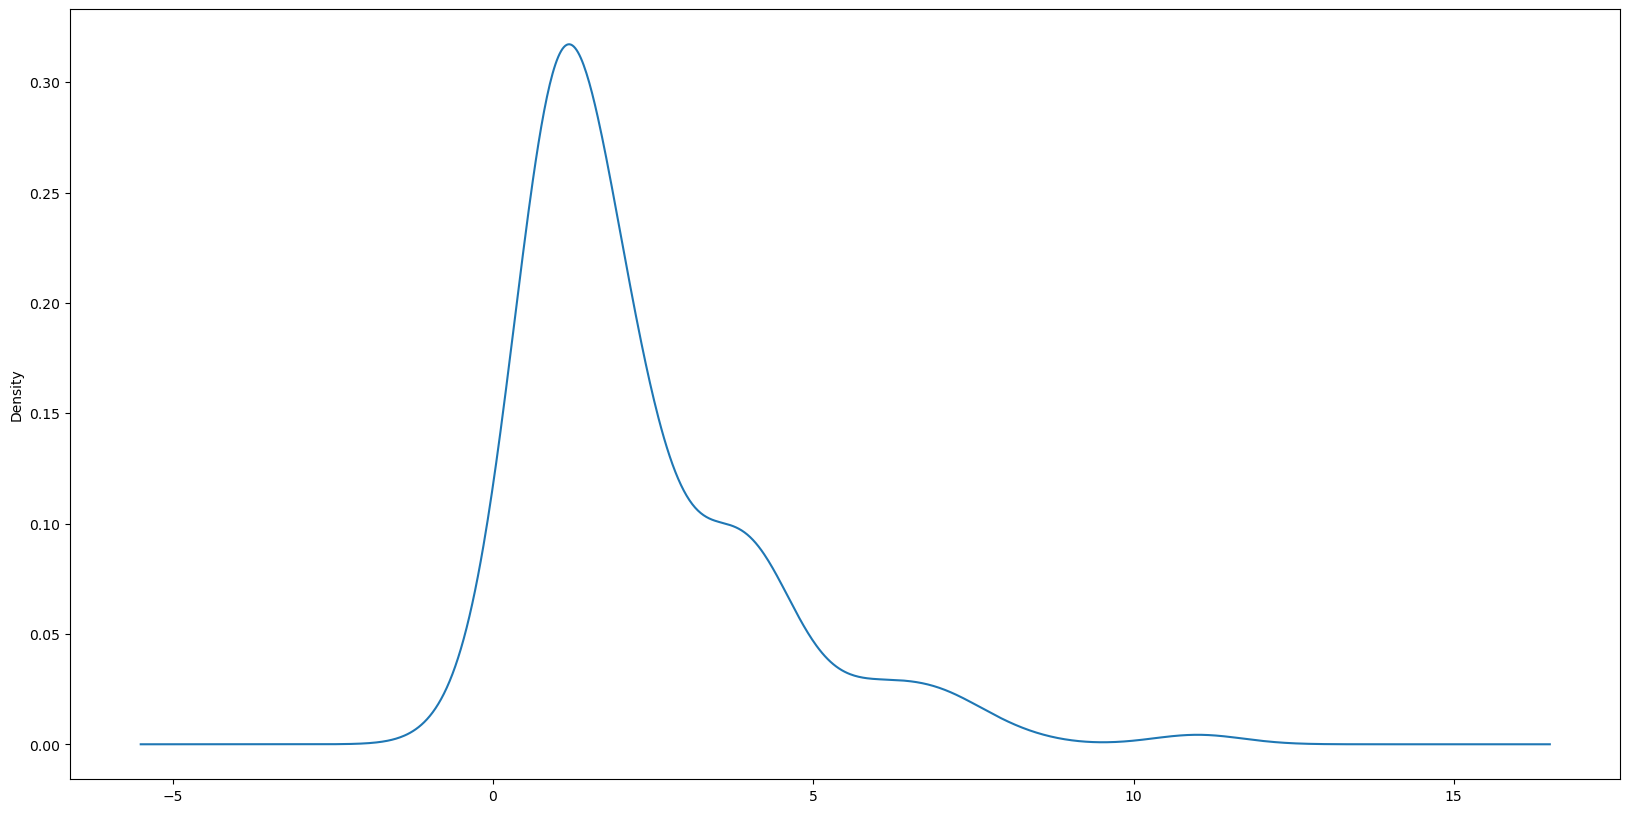

In [24]:
# Density Plots
df_comp["#ofphonelines"].plot(kind='kde', figsize=(20, 10))
pyplot.show()

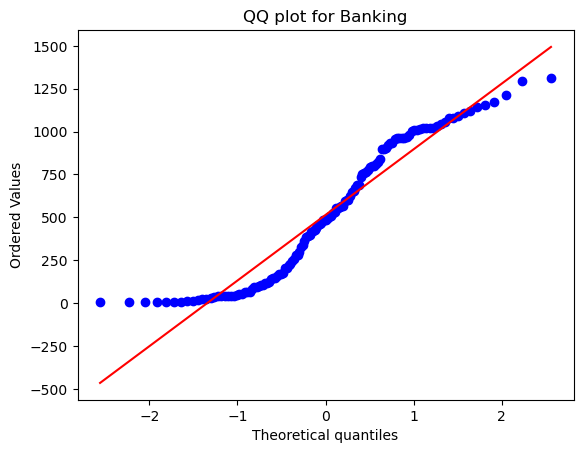

In [26]:
# The QQ plot
scipy.stats.probplot(df_comp["Banking"], plot=pylab)
plt.title("QQ plot for Banking")
pylab.show()

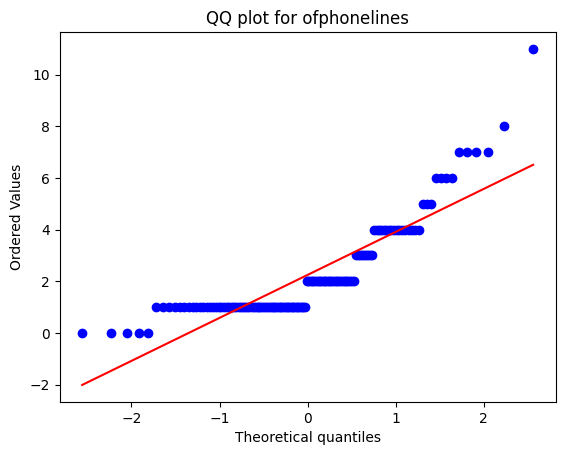

In [ ]:
# The QQ plot
scipy.stats.probplot(df_comp["#ofphonelines"], plot=pylab)
plt.title("QQ plot for ofphonelines")
pylab.show()

## Multiple Linear Regressions

In [19]:
df_comp = df_comp[["Banking","#noofchannels", "#ofphonelines"]]

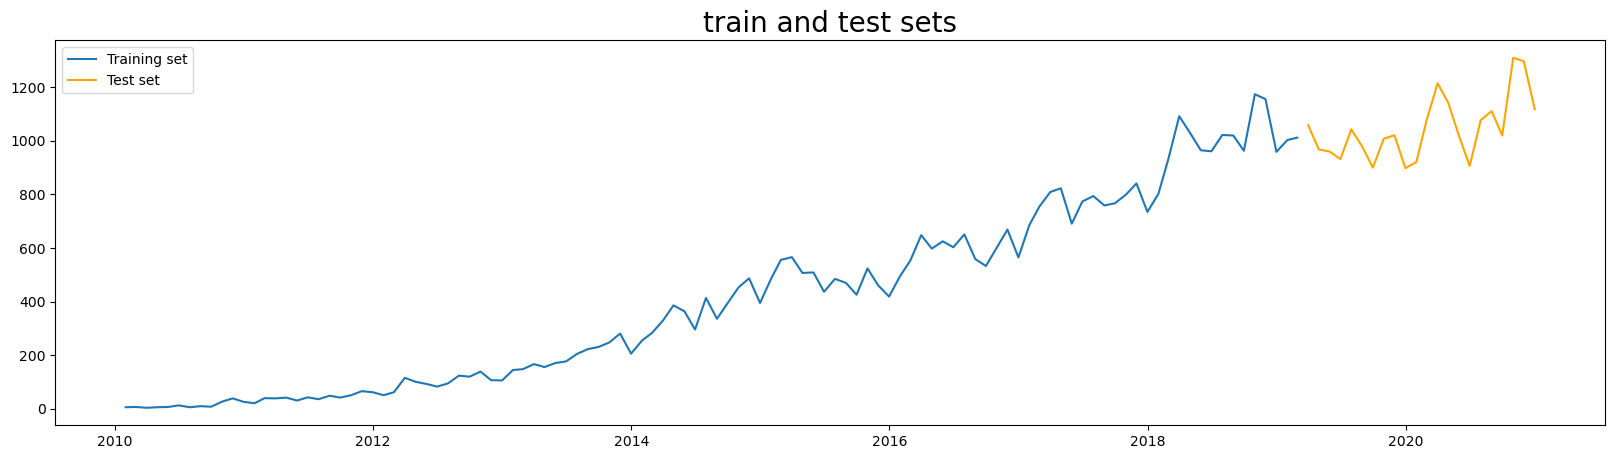

In [20]:
# train set split
test_size = 22

df_train = df_comp[:-test_size]
df_test = df_comp[-test_size:]

plt.figure(figsize=(20,5))
plt.title('train and test sets', size=20)
plt.plot(df_train["Banking"], label='Training set')
plt.plot(df_test["Banking"], label='Test set', color='orange')

plt.legend();

In [21]:
X_train = df_train[["#noofchannels", "#ofphonelines"]].values
y_train = df_train["Banking"].values

X_test = df_test[["#noofchannels", "#ofphonelines"]].values
y_test = df_test["Banking"].values

In [31]:
# train multiple LR
from sklearn.linear_model import LinearRegression
import time 

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

t0 = time.time()
lr_y = y_test
lr_y_fit = lr_model.predict(X_train)
lr_y_pred = lr_model.predict(X_test)
tF = time.time()

print('Time to train = %.2f seconds' % (tF - t0))


Time to train = 0.00 seconds


In [32]:
lr_residuals = lr_y_pred - lr_y

In [33]:
lr_rmse = np.sqrt(np.sum(np.power(lr_residuals,2)) / len(lr_residuals))
print('RMSE = %.2f' % lr_rmse)

RMSE = 503.79


the RMSE is very high, that means this model is not a good predictor the raison for that we alredy know that the data is not normally distributed


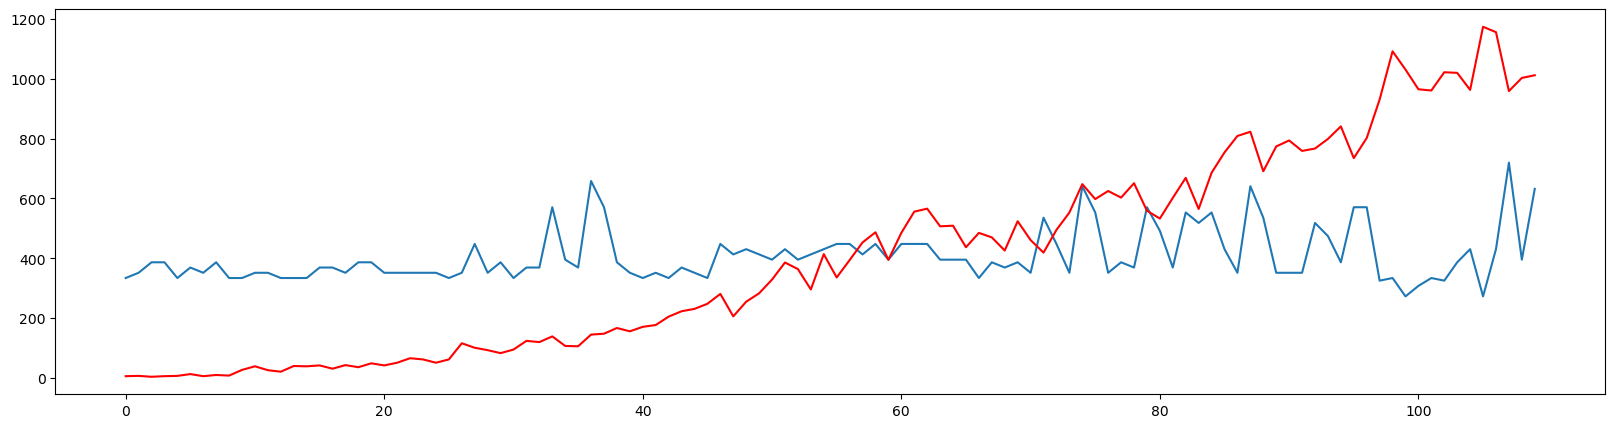

In [34]:
# plot
plt.figure(figsize=(20,5))
plt.plot(lr_y_fit)
plt.plot(y_train, color='red')
plt.show()

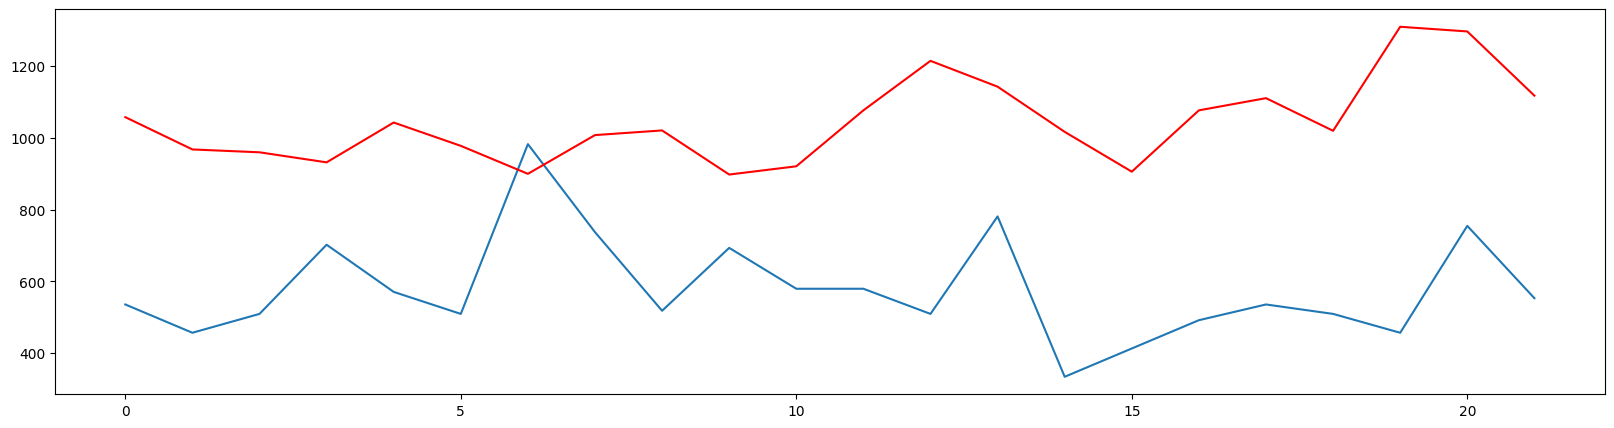

In [ ]:
# plot
plt.figure(figsize=(20,5))
plt.plot(lr_y_pred)
plt.plot(lr_y, color='red')
plt.show()

## Residual Analysis

This data is not autocorolate. lets make this data stationnary

In [23]:
df_comp["delta_1_Banking"] = df_comp.Banking.diff(1)

In [24]:
df_comp.head()

,Banking,#noofchannels,#ofphonelines,delta_1_noofchannels,delta_1_ofphonelines,delta_1_Banking
month,,,,,,
2010-01-31,6,4,1,NaN,NaN,NaN
2010-02-28,7,3,1,-1.0,0.0,1.0
2010-03-31,4,1,1,-2.0,0.0,-3.0
2010-04-30,6,1,1,0.0,0.0,2.0
2010-05-31,7,4,1,3.0,0.0,1.0


<Axes: xlabel='month'>

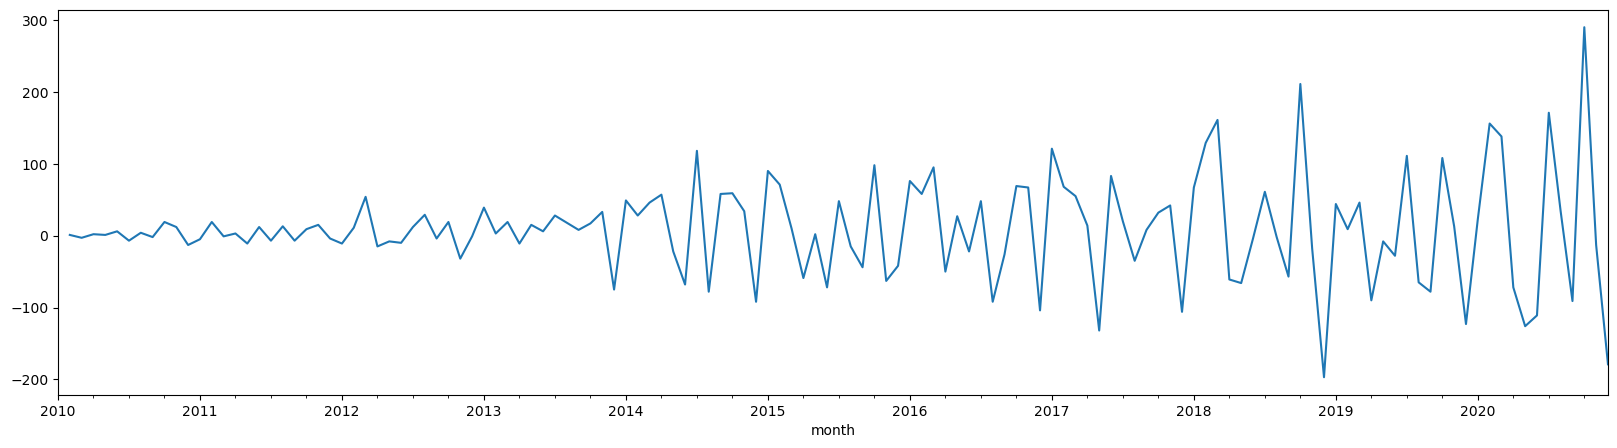

In [40]:
df_comp.delta_1_Banking.plot(figsize=(20,5))

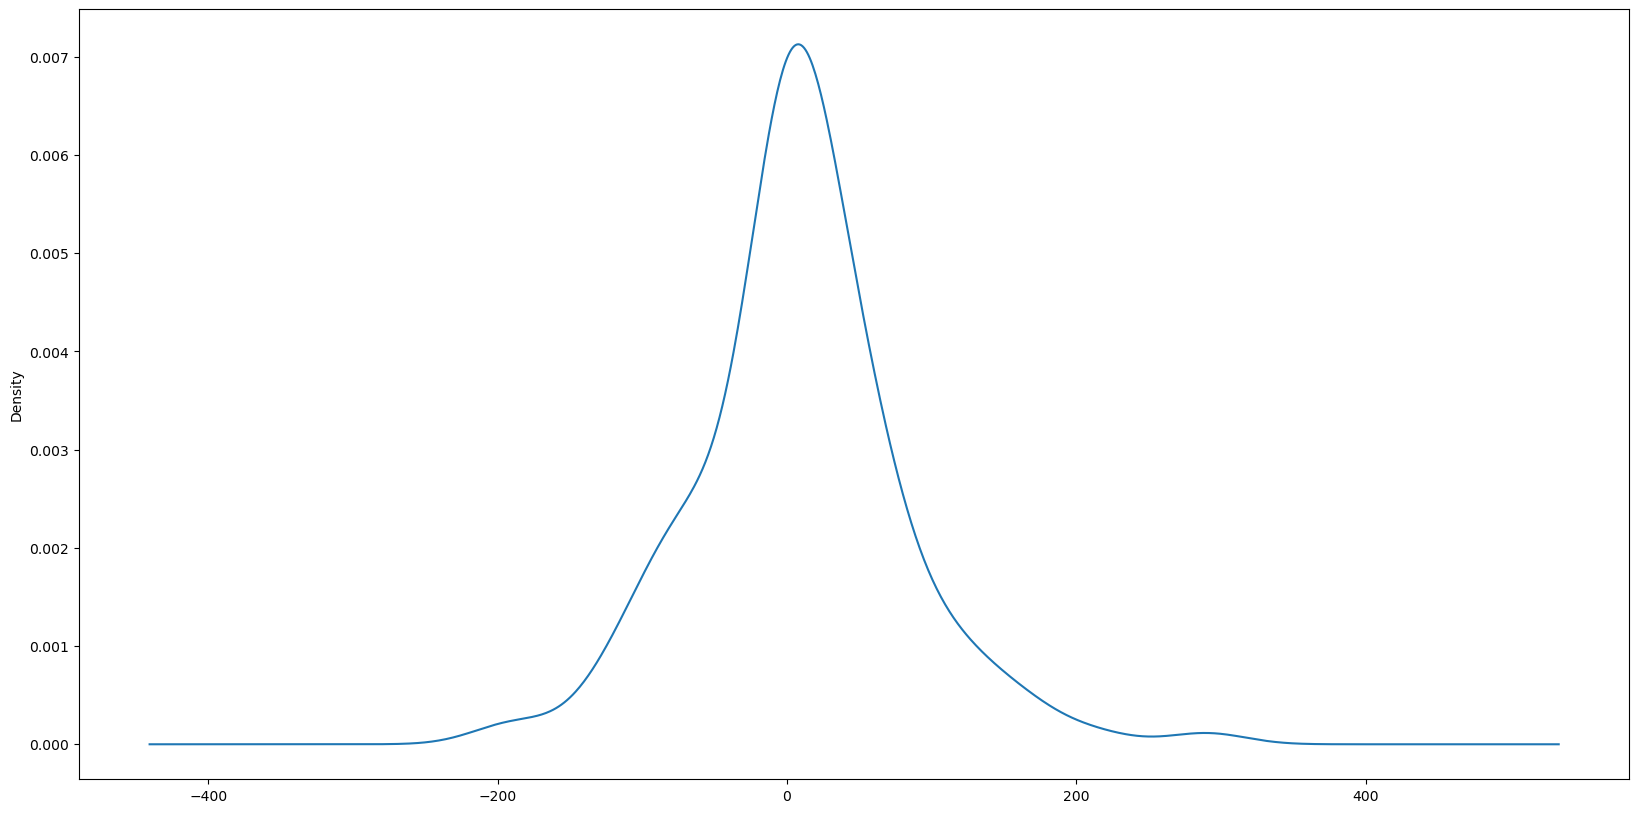

In [41]:
# Checking the normality again with Density Plots
df_comp["delta_1_Banking"].plot(kind='kde', figsize=(20, 10))
pyplot.show()

Banking data follows normallity now


In [22]:
df_comp["delta_1_noofchannels"] = df_comp["#noofchannels"].diff(1)
df_comp["delta_1_ofphonelines"] = df_comp["#ofphonelines"].diff(1)
# ofphonelines

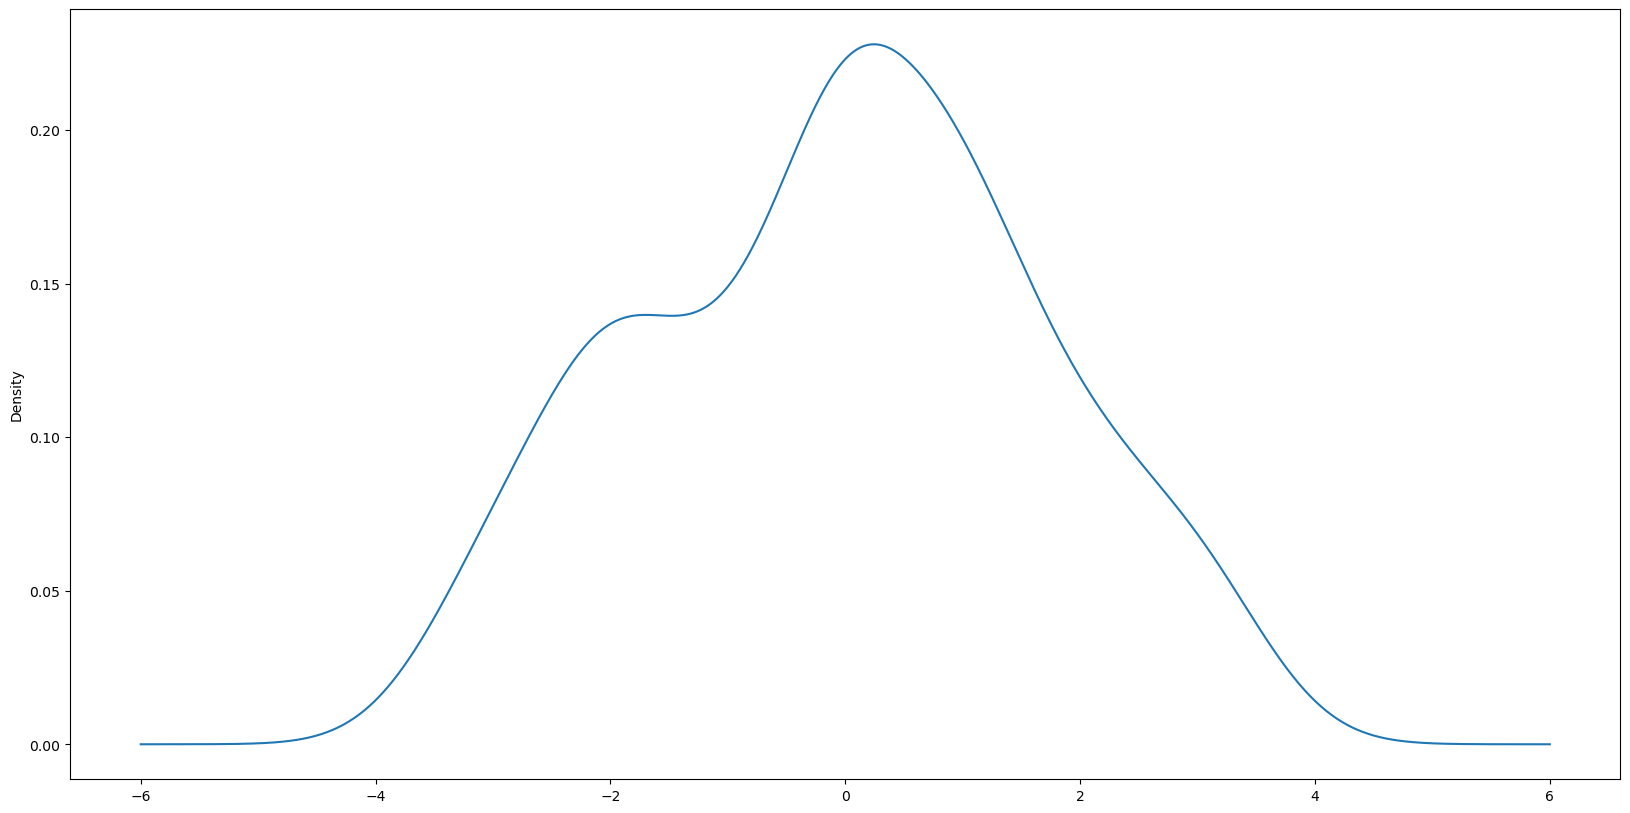

In [43]:
# Density Plots
df_comp["delta_1_noofchannels"].plot(kind='kde', figsize=(20, 10))
pyplot.show()

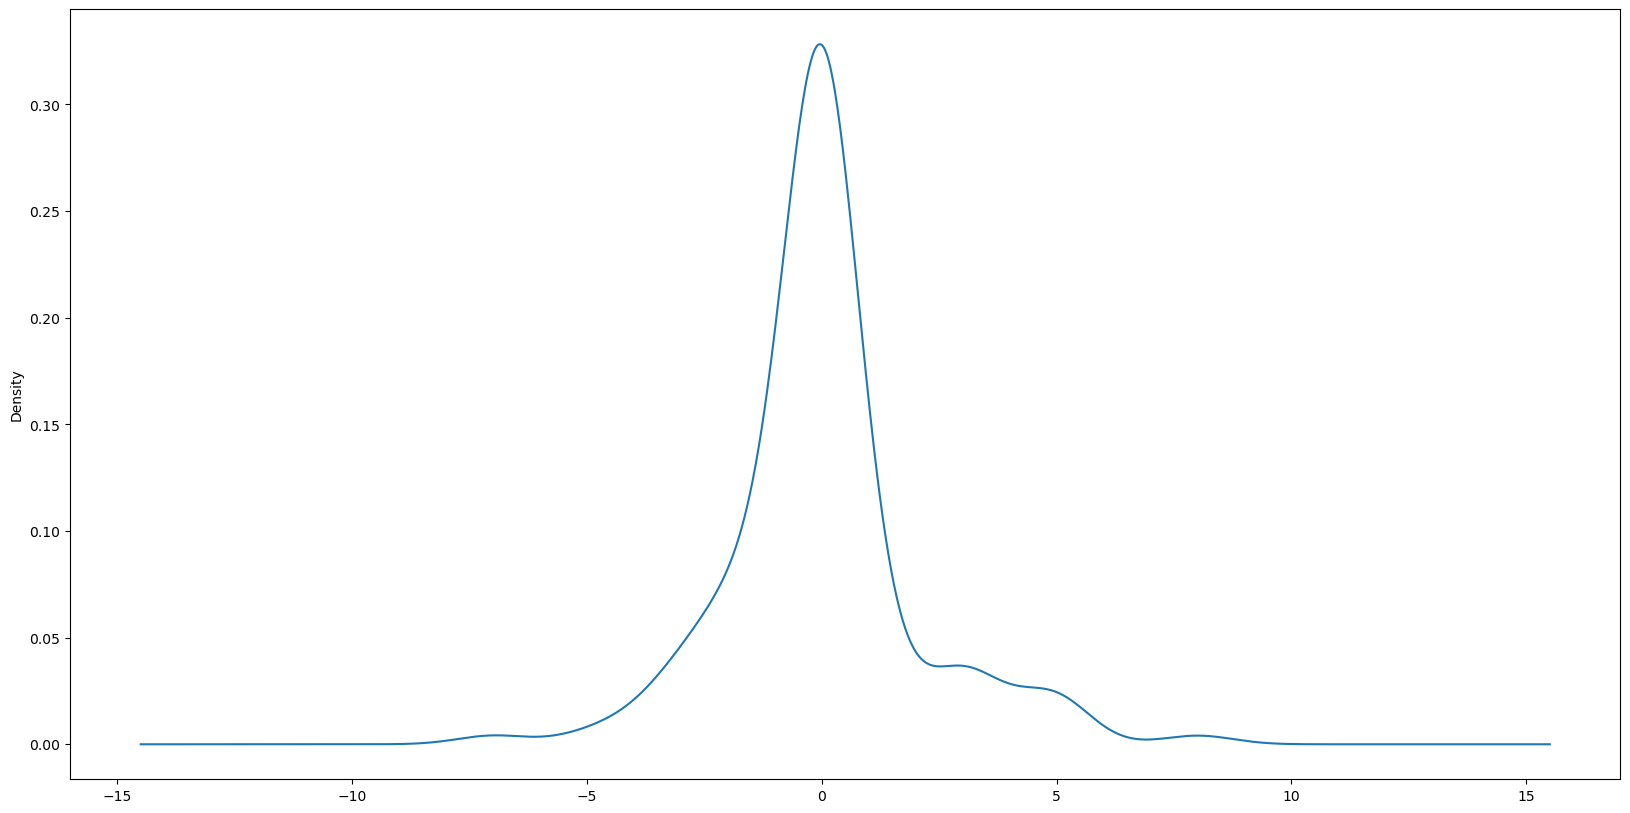

In [44]:
# Density Plots
df_comp["delta_1_ofphonelines"].plot(kind='kde', figsize=(20, 10))
pyplot.show()

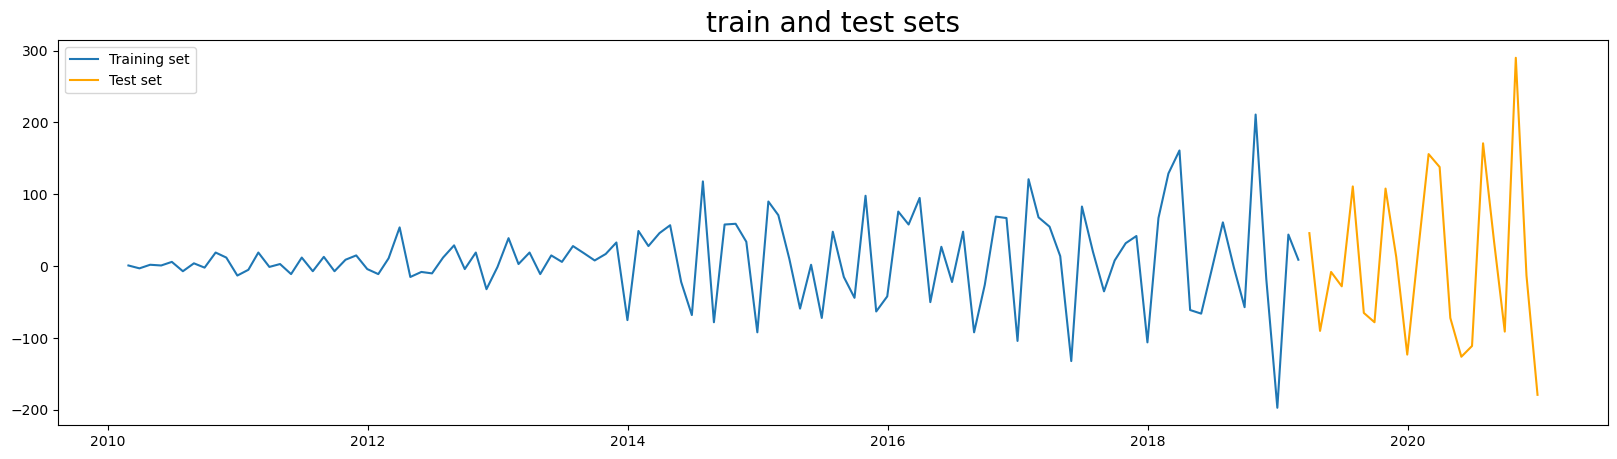

In [25]:
# train set split
test_size = 22

df_train = df_comp[:-test_size]
df_test = df_comp[-test_size:]

plt.figure(figsize=(20,5))
plt.title('train and test sets', size=20)
plt.plot(df_train.delta_1_Banking, label='Training set')
plt.plot(df_test.delta_1_Banking, label='Test set', color='orange')

plt.legend();

In [26]:
X_train = df_train[["delta_1_noofchannels", "delta_1_ofphonelines"]].values[1:]
y_train = df_train["delta_1_Banking"].values[1:]

X_test = df_test[["delta_1_noofchannels", "delta_1_ofphonelines"]].values[1:]
y_test = df_test["delta_1_Banking"].values[1:]

In [47]:
# train multiple LR
from sklearn.linear_model import LinearRegression
import time 

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

t0 = time.time()
lr_y = y_test
lr_y_fit = lr_model.predict(X_train)
lr_y_pred = lr_model.predict(X_test)
tF = time.time()

print('Time to train = %.2f seconds' % (tF - t0))


Time to train = 0.00 seconds


In [48]:
lr_residuals = lr_y_pred - lr_y

In [49]:
lr_rmse = np.sqrt(np.sum(np.power(lr_residuals,2)) / len(lr_residuals))
print('RMSE = %.2f' % lr_rmse)

RMSE = 118.87


we have a considerable reduction of RMSE compatiravely to the previous

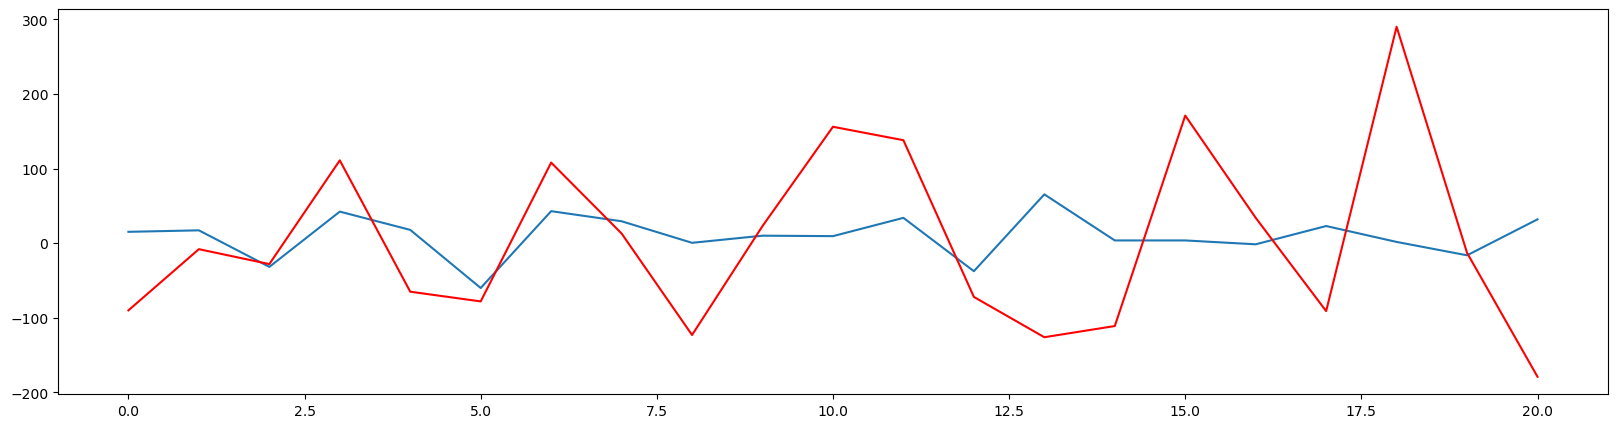

In [50]:
# plot
plt.figure(figsize=(20,5))
plt.plot(lr_y_pred)
plt.plot(lr_y, color='red')
plt.show()

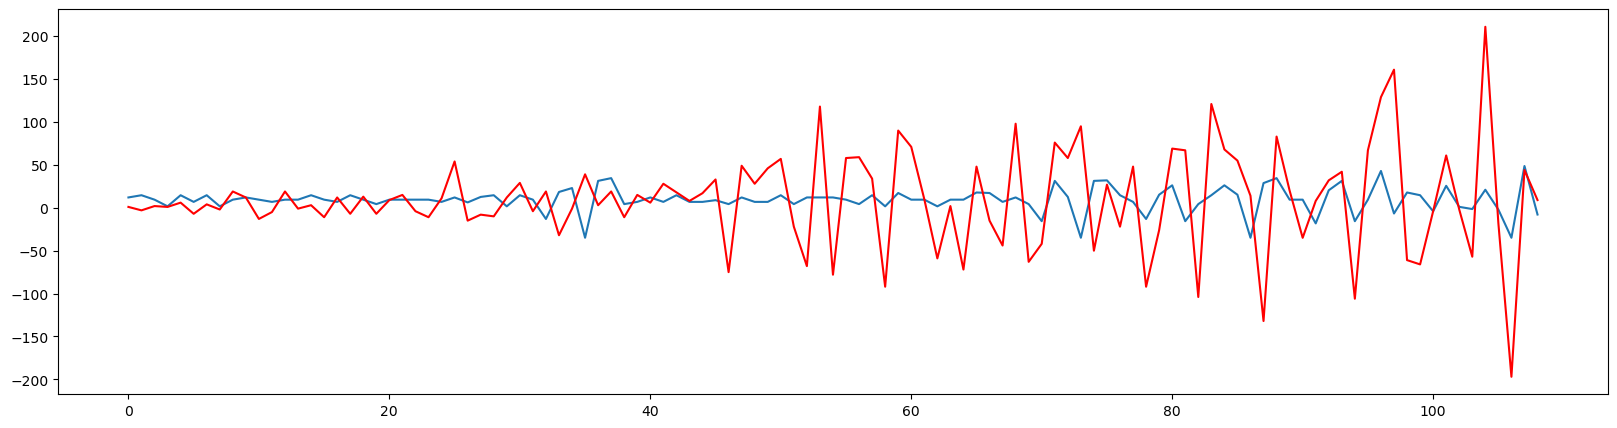

In [51]:
# plot
plt.figure(figsize=(20,5))
plt.plot(lr_y_fit)
plt.plot(y_train, color='red')
plt.show()

In [27]:
df_comp["delta_3_Banking"] = df_comp.Banking.diff(3)
df_comp["delta_3_noofchannels"] = df_comp["#noofchannels"].diff(3)
df_comp["delta_3_ofphonelines"] = df_comp["#ofphonelines"].diff(3)

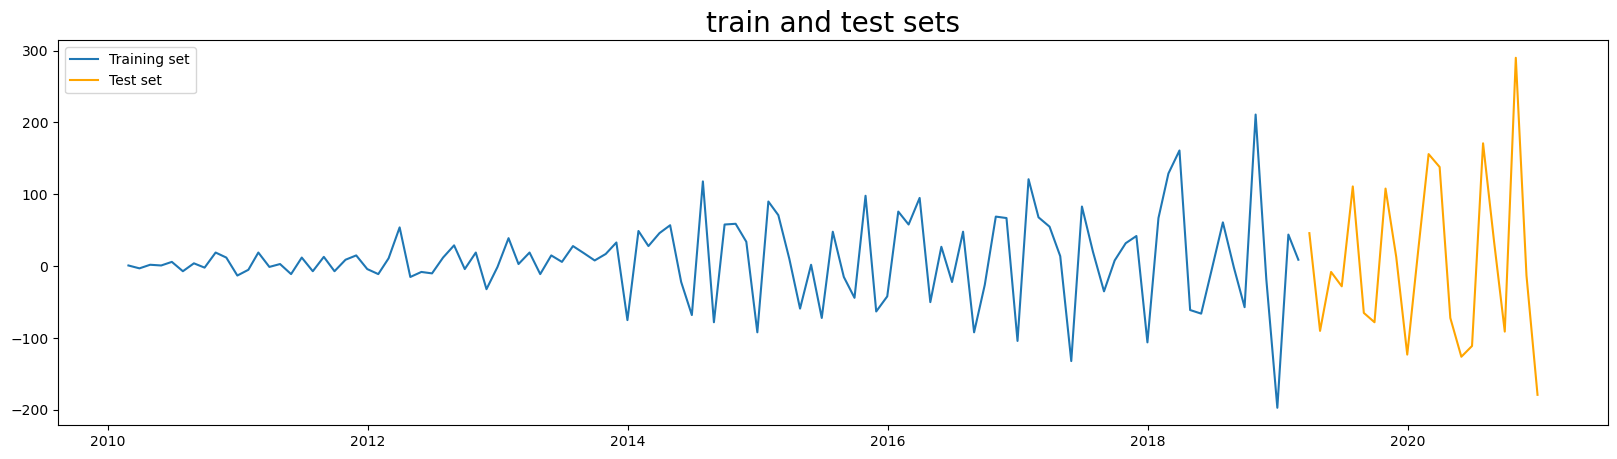

In [28]:
# train set split
test_size = 22

df_train = df_comp[:-test_size]
df_test = df_comp[-test_size:]

plt.figure(figsize=(20,5))
plt.title('train and test sets', size=20)
plt.plot(df_train.delta_1_Banking, label='Training set')
plt.plot(df_test.delta_1_Banking, label='Test set', color='orange')

plt.legend();

In [ ]:
X_train = df_train[["delta_3_noofchannels", "delta_3_ofphonelines"]].values[2:]
y_train = df_train["delta_3_Banking"].values[2:]

X_test = df_test[["delta_3_noofchannels", "delta_3_ofphonelines"]].values[2:]
y_test = df_test["delta_3_Banking"].values[2:]

In [ ]:
# train multiple LR
from sklearn.linear_model import LinearRegression
import time 

lr_model = LinearRegression()
lr_model.fit(X_train[3:], y_train[3:])

t0 = time.time()
lr_y = y_test[3:]
lr_y_fit = lr_model.predict(X_train[3:])
lr_y_pred = lr_model.predict(X_test[3:])
tF = time.time()

print('Time to train = %.2f seconds' % (tF - t0))

lr_residuals = lr_y_pred - lr_y
lr_rmse = np.sqrt(np.sum(np.power(lr_residuals,2)) / len(lr_residuals))
print('RMSE = %.2f' % lr_rmse)

Time to train = 0.00 seconds
RMSE = 157.63


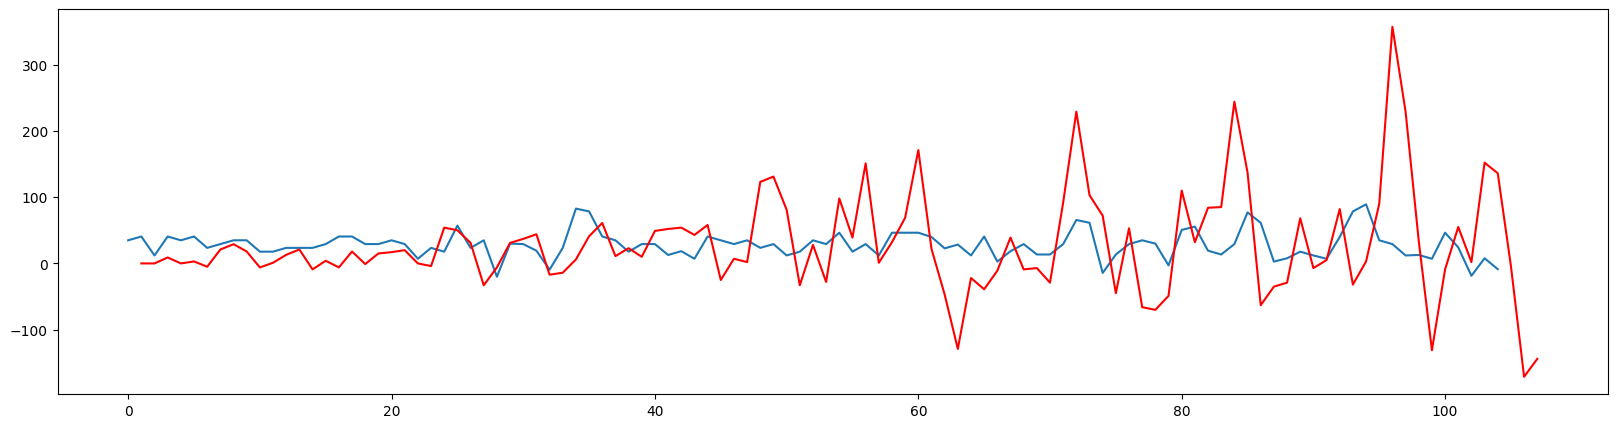

In [ ]:
# plot
plt.figure(figsize=(20,5))
plt.plot(lr_y_fit)
plt.plot(y_train, color='red')
plt.show()

## SymbolicRegressor

In [3]:
#######################
# CREATION OF THE MODEL
#######################

import gplearn as gpl        
from gplearn.genetic import SymbolicRegressor

# It is possible to create custom operations to be considered in the tree
def _xexp( x ):
    a = np.exp(x); 
    a[ np.abs(a) > 1e+9 ] = 1e+9
    return a    

In [6]:

xexp = gpl.functions.make_function( function = _xexp, name='xexp', arity=1 )
function_set = ['add', 'sub', 'mul', 'div', 'sin', 'log' , xexp]
# function_set = ['add', 'sub', 'mul', 'div']



In [7]:
if 'model' in locals(): del model
model = SymbolicRegressor(population_size = 1000, tournament_size=5,
                          generations = 25, stopping_criteria=0.1,
                          function_set = function_set, metric='rmse',
                          p_crossover=0.65, p_subtree_mutation=0.15,
                          p_hoist_mutation=0.05, p_point_mutation=0.1,
                          verbose = 1, random_state = None, n_jobs = -1)

#Please set the n_jobs = 1 if you face multiprocessing or out of the memory issues 



In [29]:
X_train = df_train[["delta_1_noofchannels", "delta_1_ofphonelines"]].values[1:]
y_train = df_train["delta_1_Banking"].values[1:]

X_test = df_test[["delta_1_noofchannels", "delta_1_ofphonelines"]].values[1:]
y_test = df_test["delta_1_Banking"].values[1:]

In [32]:
###########################################################
# TRAIN THE NETWORK AND PREDICT - Without previous values y
###########################################################

# Train
t0 = time.time()
model.fit(X_train, y_train)
tF = time.time()

# Predict
sr_y_fit = model.predict(X_train).reshape(-1,1)
sr_y_pred = model.predict(X_test).reshape(-1,1)


    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    16.14      1.77624e+14        7          57.0423              N/A      1.98m
   1    14.74      4.62615e+06       50          56.7768              N/A     56.91s
   2    17.95      8.34432e+06       54          56.3892              N/A      2.98m
   3    23.35      1.18926e+07       12          56.3747              N/A      6.75m
   4    27.41      3.10537e+06       43          55.9807              N/A      8.53m
   5    32.63      4.88046e+06       59          55.9424              N/A      8.81m
   6    37.18      4.12798e+07       59          55.8636              N/A     10.96m
   7    41.94      2.72983e+06       24          55.3652              N/A     10.84m
   8    48.05      5.48542e+06      108          53.8111              N/A  

In [ ]:
# Calculating Errors
sr_residuals = sr_y_pred - y_test
sr_rmse = np.sqrt(np.sum(np.power(sr_residuals,2)) / len(sr_residuals))
print('RMSE = %f' % sr_rmse)
print('Time to train %.2f' % (tF - t0))
print(model._program)

RMSE = 828.648909
Time to train 13.24
add(add(add(xexp(sub(div(-0.443, log(mul(X0, X1))), add(X0, X1))), log(xexp(mul(xexp(mul(sub(div(0.056, 0.880), add(X1, -0.571)), add(log(0.895), sin(X0)))), mul(sub(sin(sub(sin(X0), add(X0, -0.579))), X1), xexp(div(X1, X1))))))), sin(mul(X0, 0.476))), mul(sub(sin(X1), sin(X0)), mul(add(X0, X1), mul(xexp(X0), add(X0, -0.579)))))


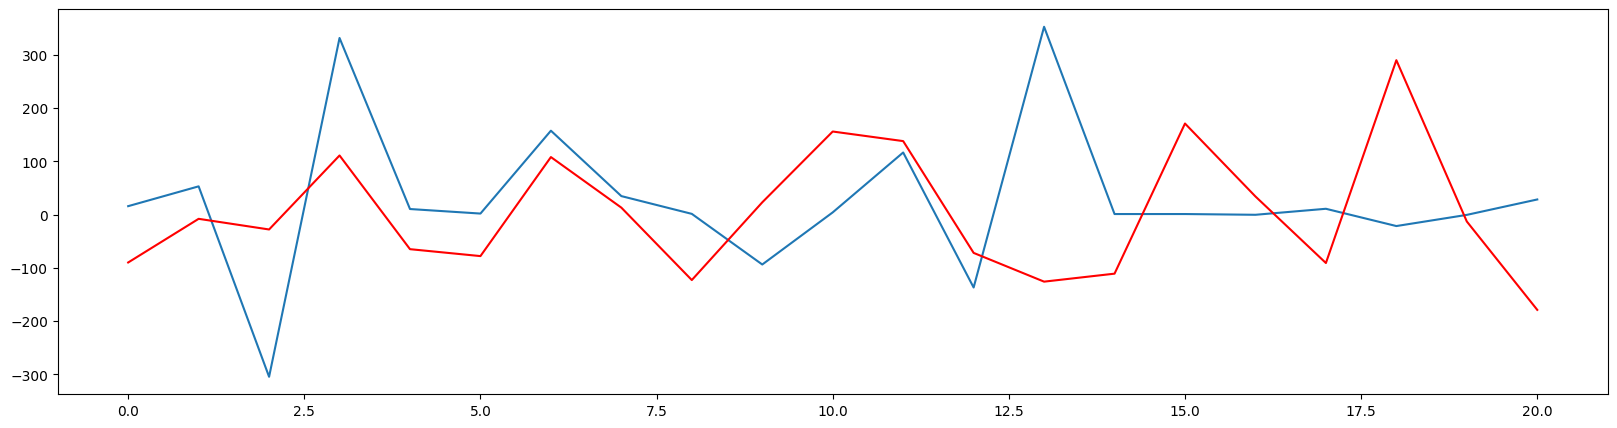

In [ ]:
# plot
plt.figure(figsize=(20,5))
plt.plot(sr_y_pred)
plt.plot(y_test, color='red')
plt.show()